**DOMINIO DEL PROBLEMA**

El problema se enmarca en el sector inmobiliario, específicamente en la valoración de propiedades residenciales. Este tipo de análisis es fundamental en economía, finanzas y bienes raíces, donde la estimación del precio de una vivienda permite apoyar decisiones de compra, venta e inversión.

**UTILIDAD**

Esta base de datos permite:

Predecir el precio de una vivienda a partir de sus características
Identificar los factores que más influyen en el valor de una propiedad
Apoyar la toma de decisiones en el mercado inmobiliario
Desarrollar modelos de Machine Learning aplicados a problemas reales

Es útil para compradores, vendedores, inversionistas, bancos y agentes inmobiliarios.

**DESCRIPCION GENERAL DEL DATASET**

El dataset contiene información sobre viviendas residenciales en la ciudad de Ames, Iowa (Estados Unidos).


Incluye variables relacionadas con:

Tamaño de la vivienda

Calidad de construcción

Ubicación

Año de construcción

Número de habitaciones

Características del garaje y sótano

Materiales y acabados

**VARIABLES NUMERICAS**

GrLivArea: Área habitable sobre el nivel del suelo

LotArea: Tamaño del terreno

TotalBsmtSF: Área total del sótano

GarageArea: Tamaño del garaje

YearBuilt: Año de construcción

FullBath: Número de baños completos

TotRmsAbvGrd: Número total de habitaciones

VARIABLES CATEGORICAS

Neighborhood: Vecindario

HouseStyle: Tipo de vivienda

RoofStyle: Tipo de techo

ExterQual: Calidad exterior

KitchenQual: Calidad de la cocina

GarageType: Tipo de garaje

VARIABLE DE SALIDA: Sale Price

**TIPO DE PROBLEMA**

Es de regresion porque tiene variable de salida

**PREGUNTA PRINCIPAL**

¿Se puede predecir el precio de una vivienda a partir de sus características físicas, estructurales y de ubicación?

**ENFOQUE DEL PROYECTO**

Para resolver este problema se aplican modelos de Machine Learning de regresión como:

Árboles de decisión
Random Forest
AdaBoost
XGBoost

Además, se utiliza validación cruzada y optimización de hiperparámetros para mejorar el desempeño del modelo.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

In [ ]:
import joblib

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, BaggingRegressor, RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score)

import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 100)

In [ ]:
df = pd.read_csv('/content/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
print("Data Types Summary:")
print("-" * 40)
dtype_counts = df.dtypes.value_counts()
print(dtype_counts)

print("\n\nDetailed Info:")
print("-" * 40)
df.info()

Data Types Summary:
----------------------------------------
object     43
int64      35
float64     3
Name: count, dtype: int64


Detailed Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 1

In [ ]:
print("Statistical Summary (Numerical Features):")
df.describe().transpose()

Statistical Summary (Numerical Features):


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [ ]:
#Analyze the target variable: SalePrice
print("=" * 60)
print("TARGET VARIABLE ANALYSIS: SalePrice")
print("=" * 60)

# Basic statistics
print(f"Count: {df['SalePrice'].count():,}")
print(f"Mean: ${df['SalePrice'].mean():,.2f}")
print(f"Median: ${df['SalePrice'].median():,.2f}")
print(f"Std Dev: ${df['SalePrice'].std():,.2f}")
print(f"Min: ${df['SalePrice'].min():,.2f}")
print(f"Max: ${df['SalePrice'].max():,.2f}")
print(f"Skewness: {df['SalePrice'].skew():.3f}")
print(f"Kurtosis: {df['SalePrice'].kurtosis():.3f}")

TARGET VARIABLE ANALYSIS: SalePrice
Count: 1,460
Mean: $180,921.20
Median: $163,000.00
Std Dev: $79,442.50
Min: $34,900.00
Max: $755,000.00
Skewness: 1.883
Kurtosis: 6.536


La variable objetivo SalePrice, que representa el precio de venta de las viviendas, cuenta con 1.460 observaciones. El precio promedio de las casas es de 180.921, mientras que la mediana es de 163.000, lo que indica que existen algunas viviendas con precios muy altos que elevan el promedio. La desviación estándar de $79.442 muestra una alta dispersión en los precios, es decir, existe una gran variabilidad entre viviendas económicas y viviendas de alto valor. El precio mínimo registrado fue de 34.900 y el máximo de 755.000, confirmando una amplia diferencia entre propiedades. Además, la asimetría positiva (skewness = 1.883) indica que la distribución está sesgada hacia la derecha, lo que significa que predominan viviendas de precios bajos y medios, mientras que pocas viviendas muy costosas generan una cola larga hacia valores altos. Finalmente, la curtosis elevada (6.536) sugiere la presencia de valores extremos o outliers importantes, algo común en datasets inmobiliarios.

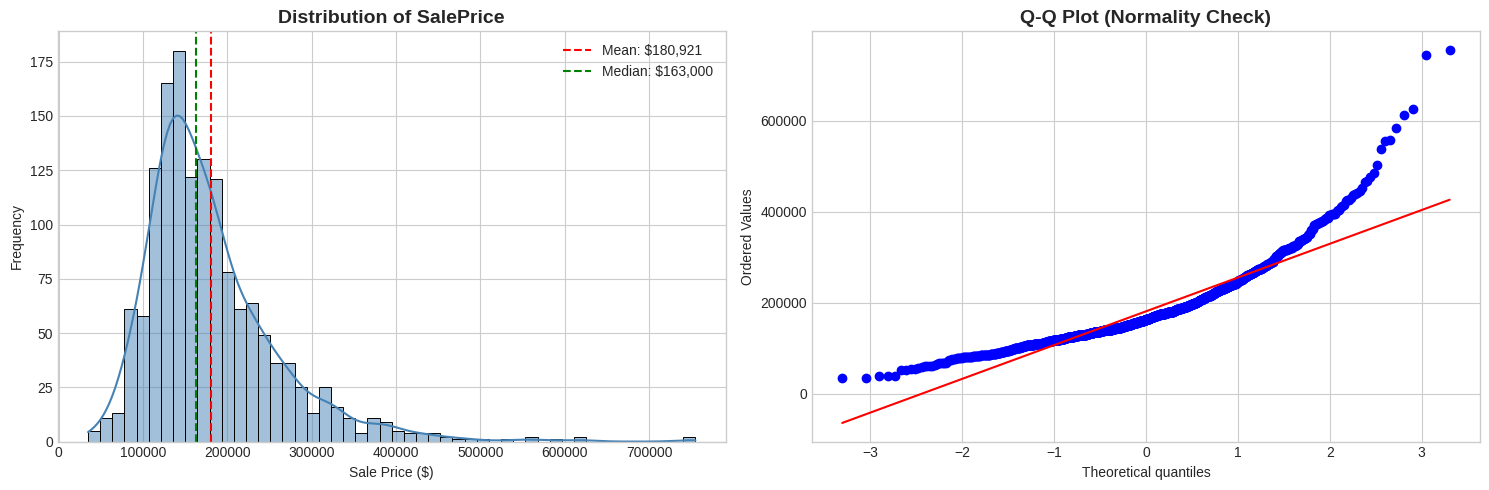

In [ ]:
#Visualize SalePrice distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram with KDE
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue', bins=50)
axes[0].set_title('Distribution of SalePrice', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f'Mean: ${df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='--', label=f'Median: ${df["SalePrice"].median():,.0f}')
axes[0].legend()

# Q-Q plot for normality check
stats.probplot(df['SalePrice'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

El histograma de SalePrice muestra que la mayor concentración de viviendas se encuentra en precios entre aproximadamente 100.000 y 200.000, lo que indica que la mayoría de las propiedades pertenecen a un rango medio de valor. Se observa claramente una cola larga hacia la derecha, lo que confirma una distribución asimétrica positiva: existen pocas viviendas con precios muy altos que elevan el promedio general. Esto también se evidencia porque la media 180.921 es mayor que la mediana 163.000, señal de que los valores extremos altos están desplazando el promedio hacia arriba.
Por otro lado, el Q-Q Plot permite evaluar si la variable sigue una distribución normal. Si los puntos siguieran aproximadamente la línea roja, podríamos asumir normalidad; sin embargo, en este caso los puntos se desvían considerablemente de la línea, especialmente en los extremos superiores, donde aparecen valores mucho más altos de lo esperado bajo una distribución normal. Esto confirma que SalePrice no sigue una distribución normal y presenta outliers importantes en la parte alta de los precios

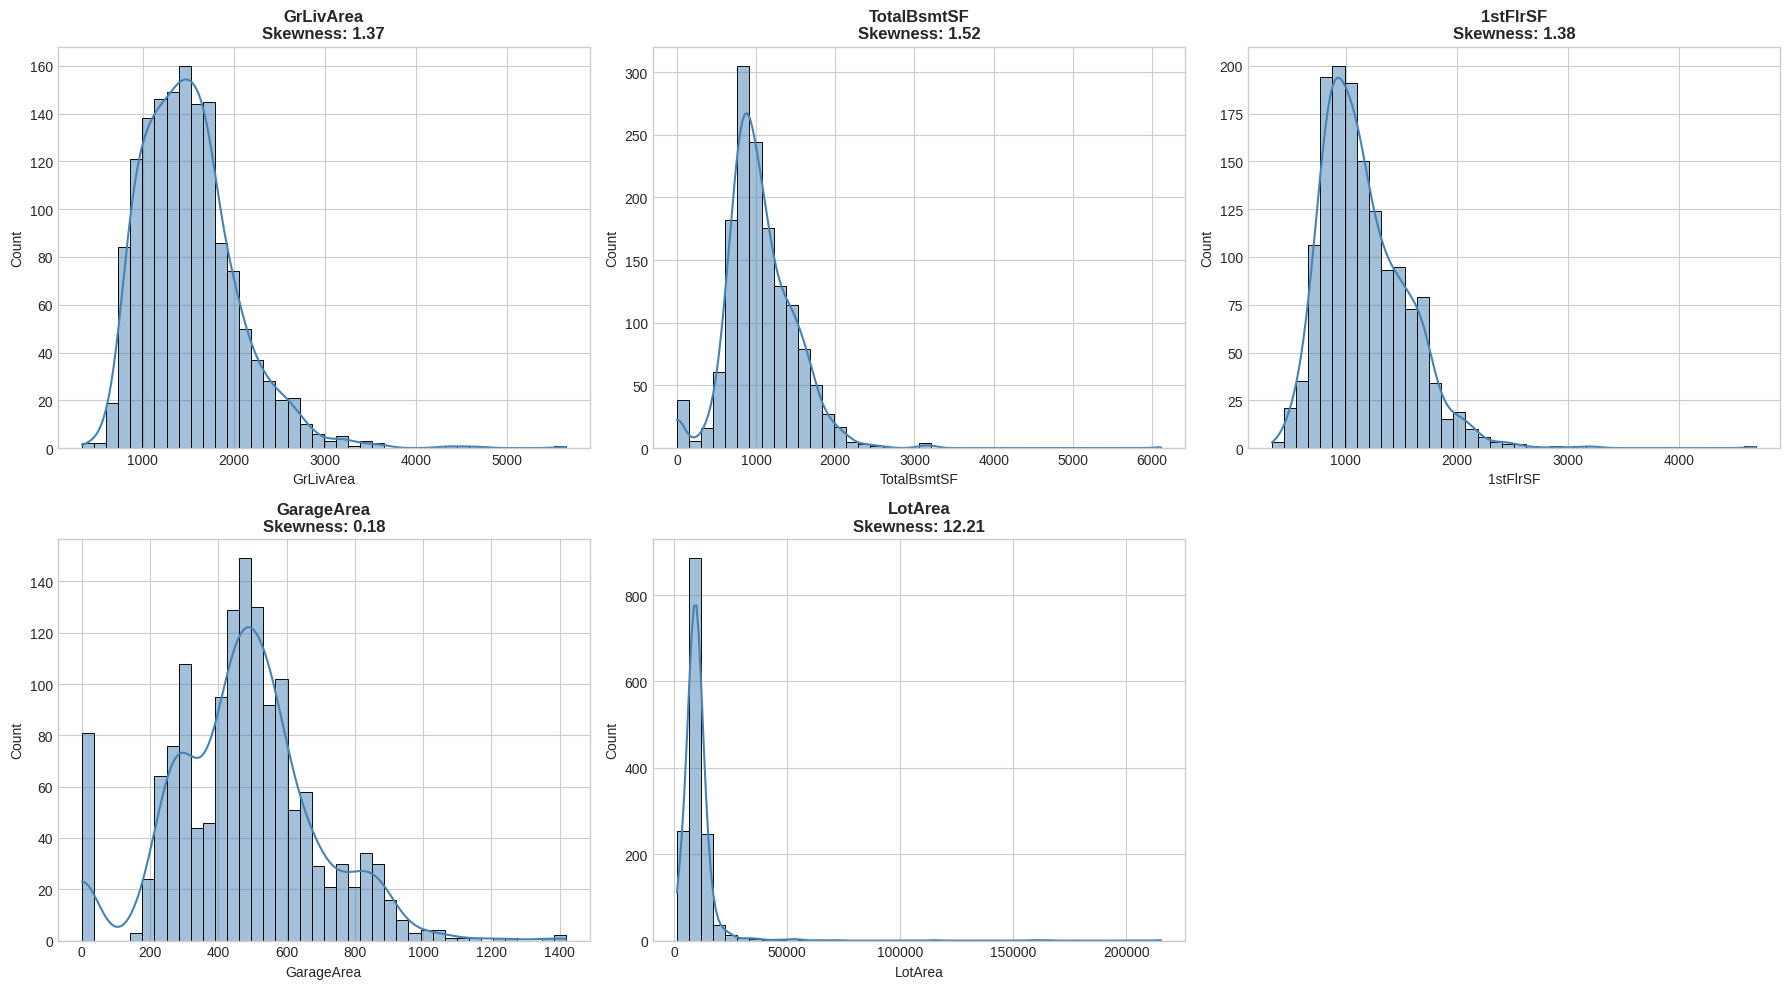

In [ ]:
#Visualize distributions of key numerical features
key_features = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'LotArea']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    if idx < len(axes):
        sns.histplot(df[feature].dropna(), kde=True, ax=axes[idx], color='steelblue', bins=40)
        axes[idx].set_title(f'{feature}\nSkewness: {df[feature].skew():.2f}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(feature)

# Remove empty subplot
if len(key_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

En GrLivArea (área habitable sobre el nivel del suelo), la mayoría de las viviendas se concentran entre 1.000 y 2.000 pies cuadrados, con una asimetría positiva (skewness = 1.37), lo que indica que existen algunas casas mucho más grandes que el promedio. En TotalBsmtSF (área total del sótano) y 1stFlrSF (área del primer piso) ocurre algo similar, con distribuciones sesgadas hacia la derecha (1.52 y 1.38 respectivamente), mostrando que la mayoría de viviendas tienen tamaños moderados, pero unas pocas presentan áreas considerablemente mayores.

Por otro lado, GarageArea presenta una distribución mucho más cercana a la normal (skewness = 0.18), lo que sugiere una menor presencia de valores extremos y una mayor estabilidad en el tamaño de los garajes. Finalmente, LotArea (área total del lote) presenta una asimetría extremadamente alta (skewness = 12.21), lo que evidencia una fuerte presencia de outliers: la mayoría de los terrenos son relativamente pequeños, pero existen algunos lotes excepcionalmente grandes que distorsionan la distribución.

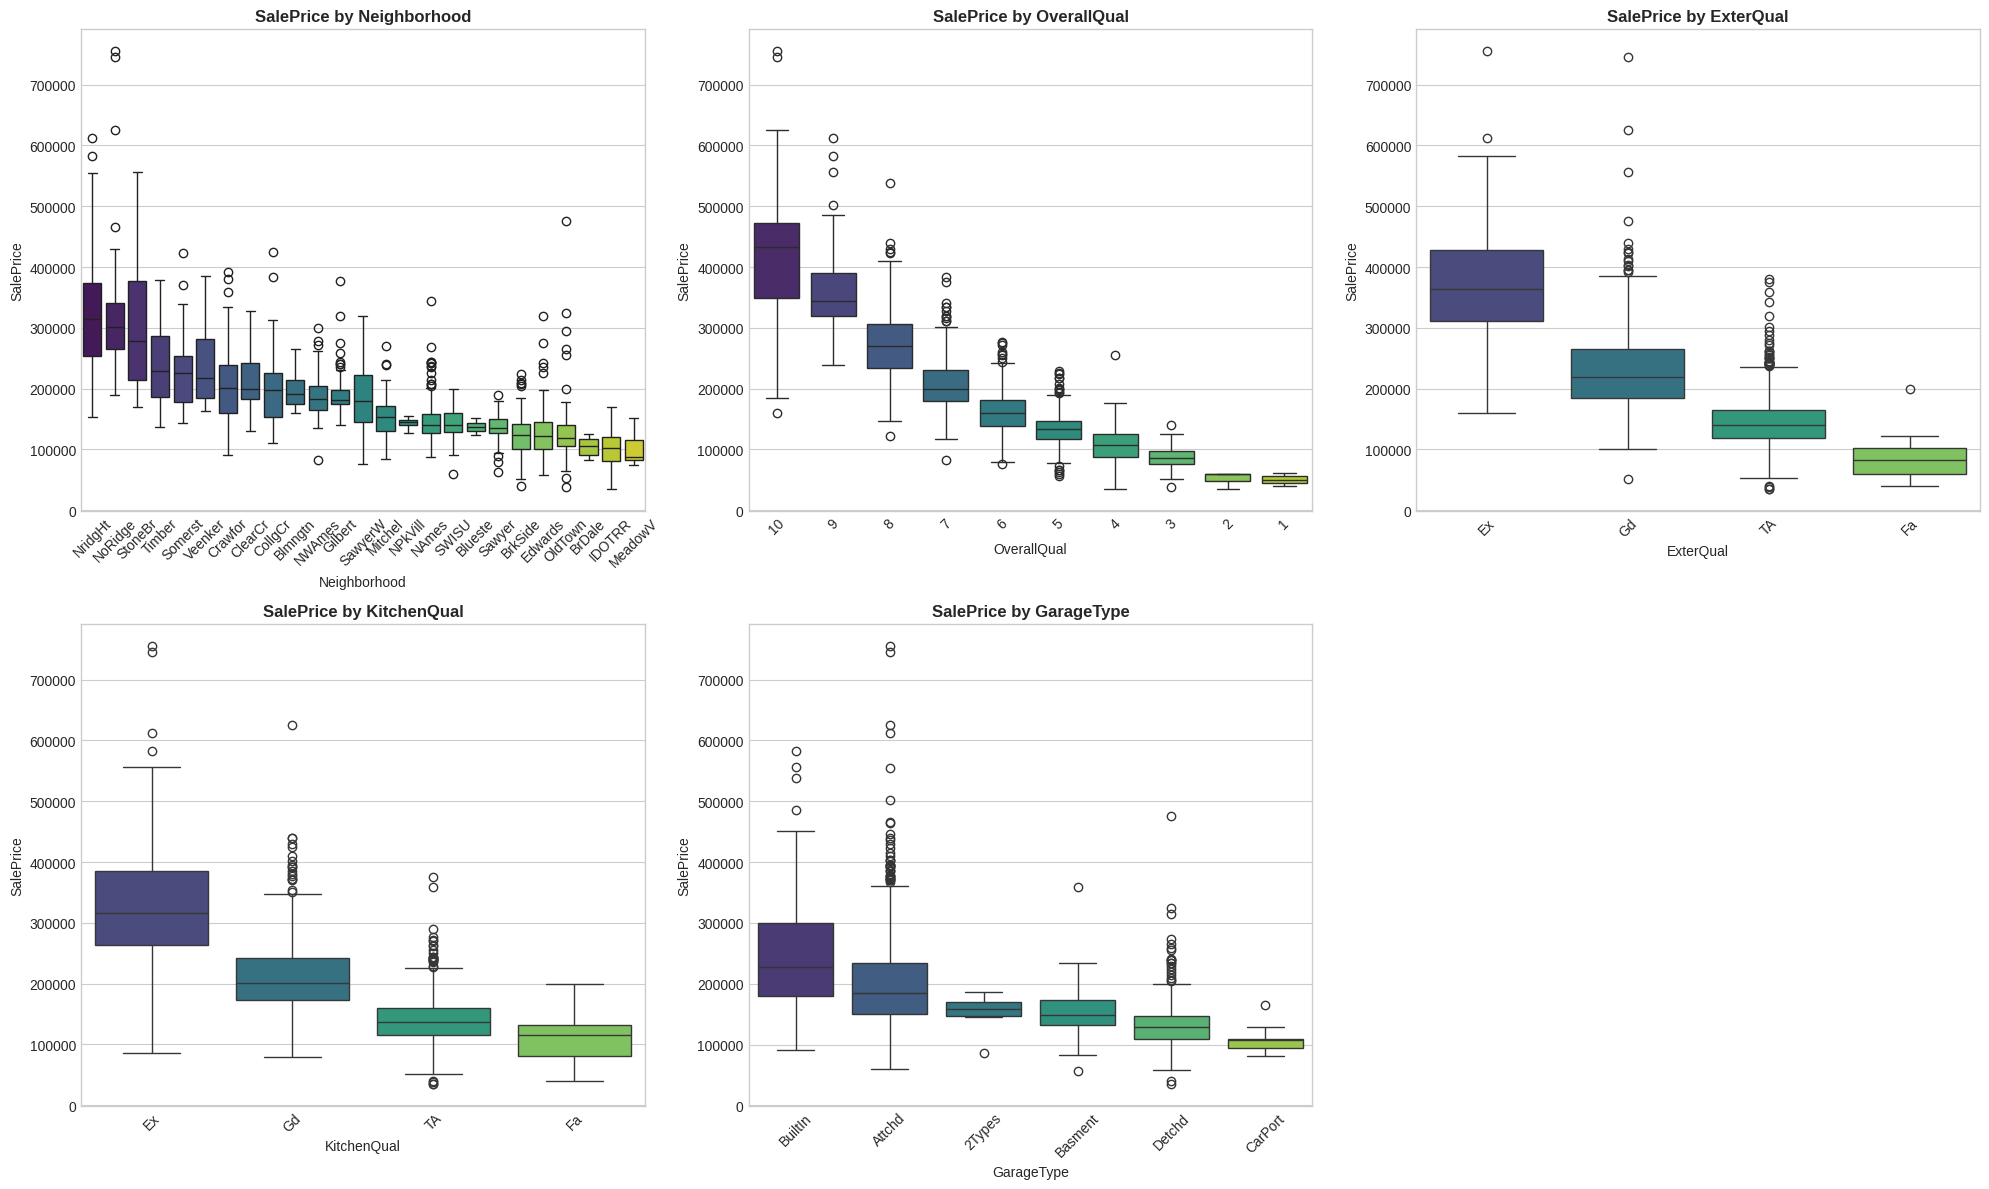

In [ ]:
#Analyze relationship between top categorical features and SalePrice
top_cat_features = ['Neighborhood', 'OverallQual', 'ExterQual', 'KitchenQual', 'GarageType']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_cat_features):
    if idx < len(axes):
        # Boxplot
        order = df.groupby(feature)['SalePrice'].median().sort_values(ascending=False).index
        sns.boxplot(data=df, x=feature, y='SalePrice', order=order, ax=axes[idx], palette='viridis')
        axes[idx].set_title(f'SalePrice by {feature}', fontsize=12, fontweight='bold')
        axes[idx].tick_params(axis='x', rotation=45)

# Remove empty subplot
if len(top_cat_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

En Neighborhood, se observa que algunos vecindarios como NridgHt, NoRidge y StoneBr presentan medianas de precio mucho más altas, lo que indica que la ubicación influye fuertemente en el valor de la vivienda. En contraste, zonas como MeadowV o IDOTRR muestran precios considerablemente más bajos. Esto confirma que el vecindario es una de las variables más relevantes en la predicción del precio.

En OverallQual (calidad general de la vivienda), se aprecia una relación muy clara y creciente: a mayor calidad, mayor precio de venta. Las viviendas con calificación 9 o 10 tienen medianas muy superiores a aquellas con calificaciones bajas, mostrando que esta variable tiene una fuerte capacidad explicativa. Lo mismo ocurre con ExterQual y KitchenQual, donde las categorías Ex (Excellent) presentan precios mucho más altos que Gd, TA o Fa, indicando que la calidad exterior y de la cocina impactan significativamente en el valor de mercado.

Finalmente, en GarageType, las viviendas con garaje tipo BuiltIn suelen presentar precios más altos que aquellas con Detchd o CarPort, aunque la diferencia es menos marcada que en las variables anteriores. Además, en casi todos los gráficos se observan numerosos outliers superiores, lo que refleja la existencia de propiedades de lujo con precios excepcionalmente altos.

In [ ]:
#Calculate correlation matrix for numerical features
corr_matrix = df[numerical_features + ['SalePrice']].corr()

# Get top correlations with SalePrice
price_correlations = corr_matrix['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False)

print("Top 15 Features Correlated with SalePrice:")
print("=" * 50)
for feature, corr in price_correlations.head(15).items():
    print(f"{feature:20s}: {corr:6.3f}")

Top 15 Features Correlated with SalePrice:
OverallQual         :  0.791
GrLivArea           :  0.709
GarageCars          :  0.640
GarageArea          :  0.623
TotalBsmtSF         :  0.614
1stFlrSF            :  0.606
FullBath            :  0.561
TotRmsAbvGrd        :  0.534
YearBuilt           :  0.523
YearRemodAdd        :  0.507
GarageYrBlt         :  0.486
MasVnrArea          :  0.477
Fireplaces          :  0.467
BsmtFinSF1          :  0.386
LotFrontage         :  0.352


La variable con mayor relación es OverallQual (0.791), lo que indica que la calidad general de la vivienda es el factor más importante para explicar el precio: a mejor calidad constructiva y de acabados, mayor valor de venta. Le sigue GrLivArea (0.709), que representa el área habitable sobre el nivel del suelo, confirmando que las casas más grandes suelen tener precios más altos.

También destacan variables relacionadas con el garaje como GarageCars (0.640) y GarageArea (0.623), lo que sugiere que la capacidad y tamaño del garaje influyen significativamente en el valor de la propiedad. De igual forma, el tamaño del sótano (TotalBsmtSF = 0.614) y el área del primer piso (1stFlrSF = 0.606) presentan una relación importante, mostrando que el espacio útil total de la vivienda impacta directamente en el precio.

Variables como FullBath, TotRmsAbvGrd, YearBuilt y YearRemodAdd también presentan correlaciones positivas moderadas, indicando que más baños, más habitaciones, viviendas más nuevas o remodeladas suelen tener mayor valor.

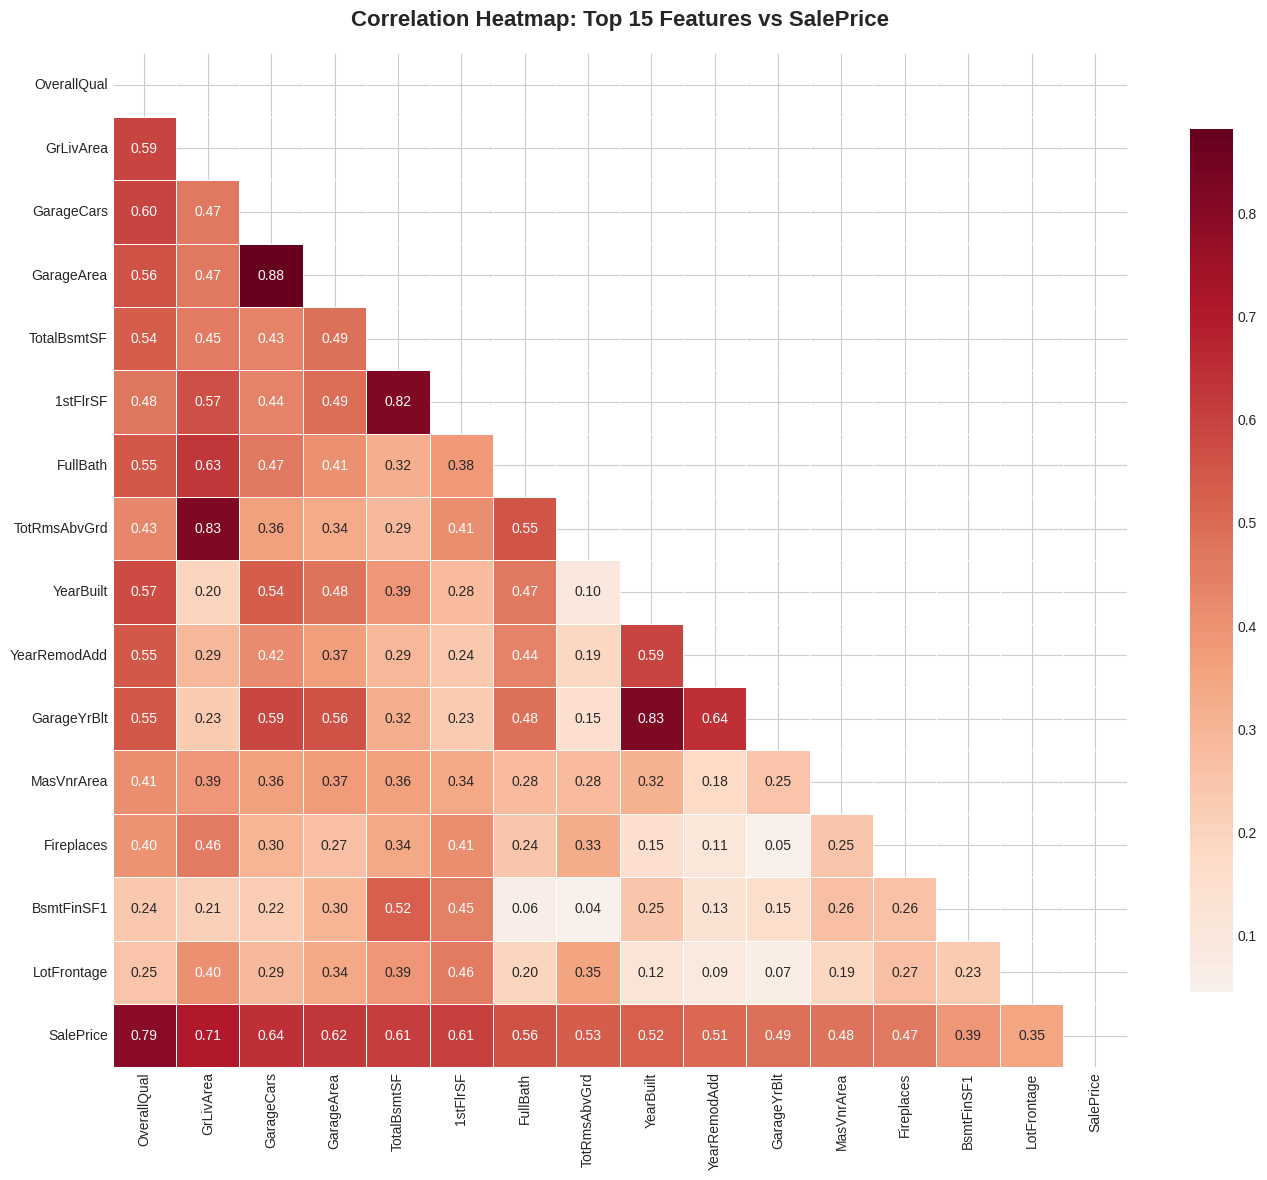

In [ ]:
#Create correlation heatmap for top features
top_features = price_correlations.head(15).index.tolist() + ['SalePrice']
top_corr_matrix = df[top_features].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(top_corr_matrix, dtype=bool))
sns.heatmap(top_corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Top 15 Features vs SalePrice', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

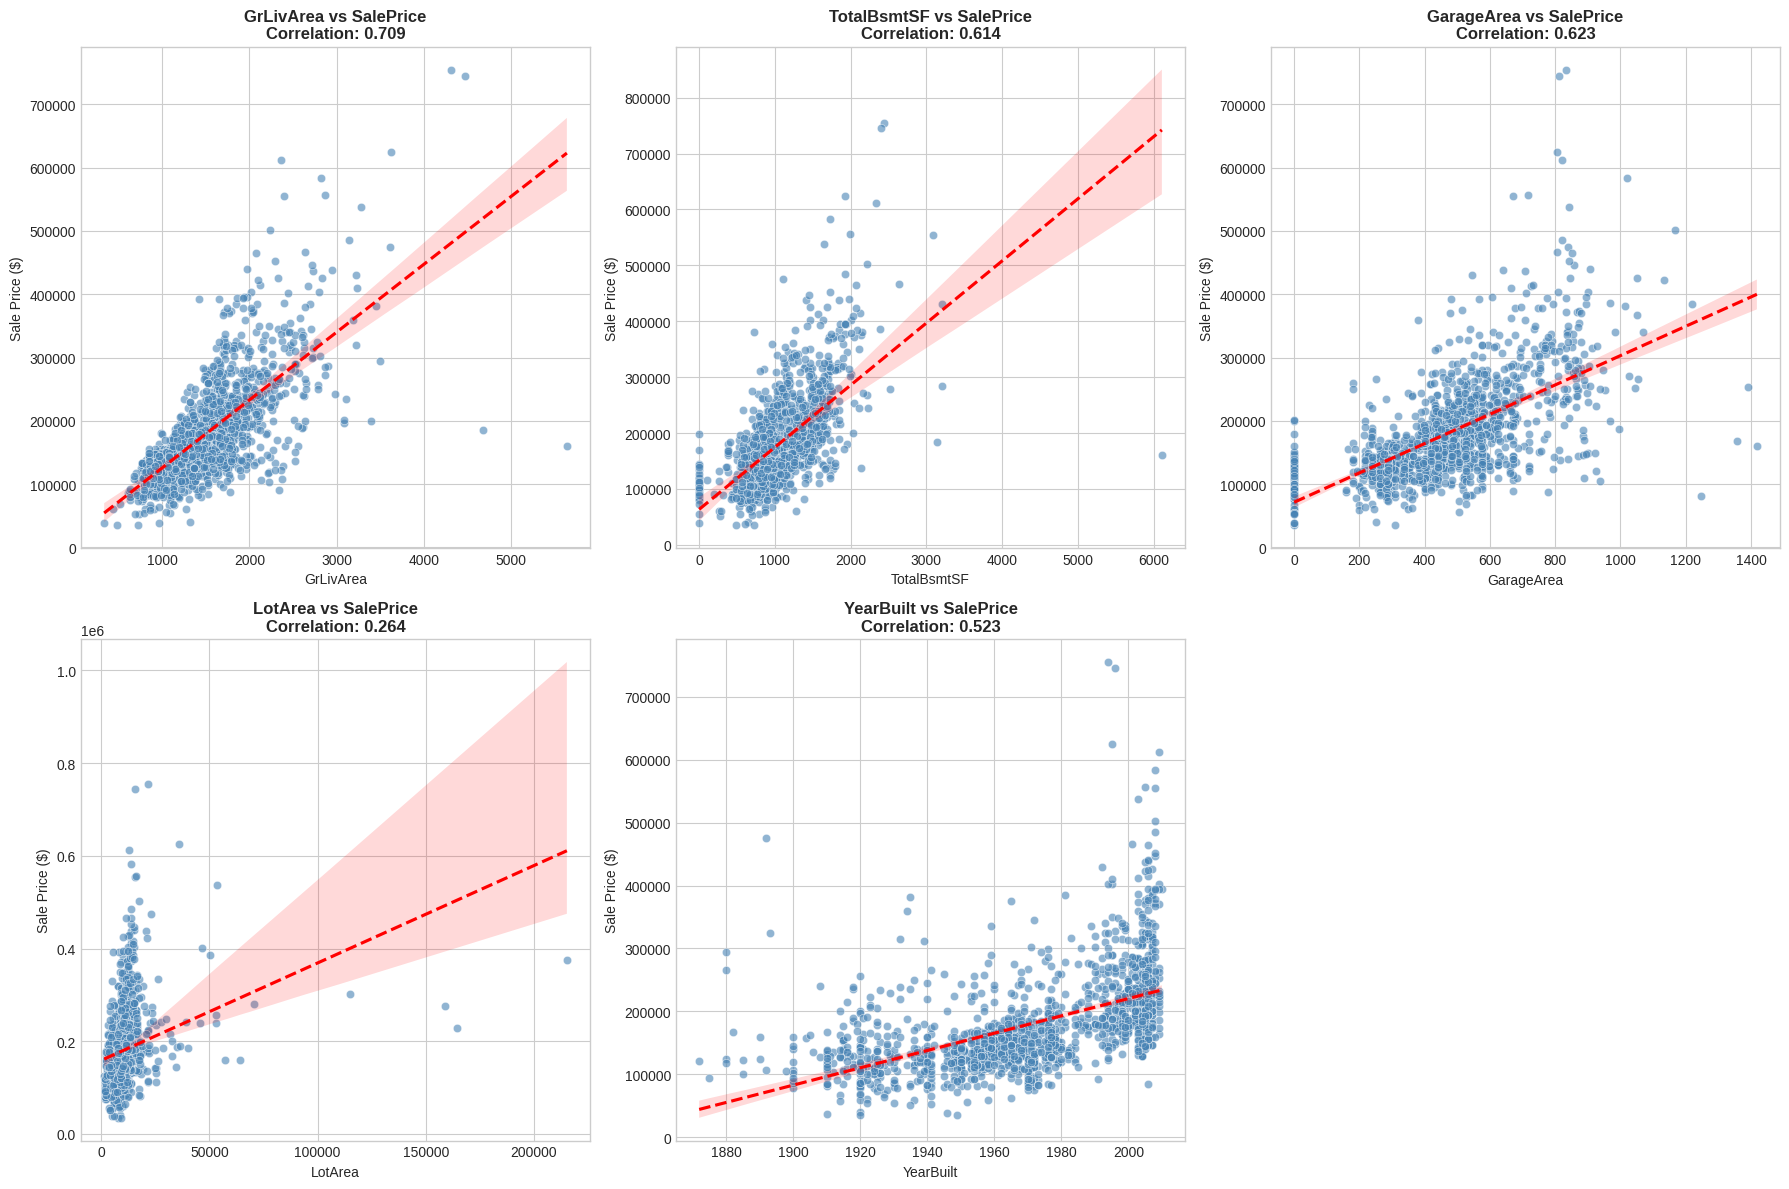

In [ ]:
#Scatter plots for top numerical features vs SalePrice
top_num_features = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_num_features):
    if idx < len(axes):
        # Scatter plot with regression line
        sns.scatterplot(data=df, x=feature, y='SalePrice', ax=axes[idx], alpha=0.6, color='steelblue')
        sns.regplot(data=df, x=feature, y='SalePrice', ax=axes[idx], scatter=False, color='red', line_kws={'linestyle': '--'})
        # Add correlation coefficient
        corr = df[feature].corr(df['SalePrice'])
        axes[idx].set_title(f'{feature} vs SalePrice\nCorrelation: {corr:.3f}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Sale Price ($)')

# Remove empty subplot
if len(top_num_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

En general, todos los gráficos muestran una relación positiva con el precio: a mayor valor de la variable, mayor tiende a ser el SalePrice. Sin embargo, no todas influyen igual.

El área habitable (GrLivArea) es la más importante, con una relación fuerte y bastante clara, lo que indica que el tamaño de la casa es el principal determinante del precio. El área del sótano y del garaje también influyen de manera moderada, aportando valor pero con más dispersión. El año de construcción sugiere que las casas más nuevas suelen ser más caras, aunque no de forma tan consistente. En cambio, el tamaño del lote tiene una relación débil, por lo que no explica bien el precio por sí solo.

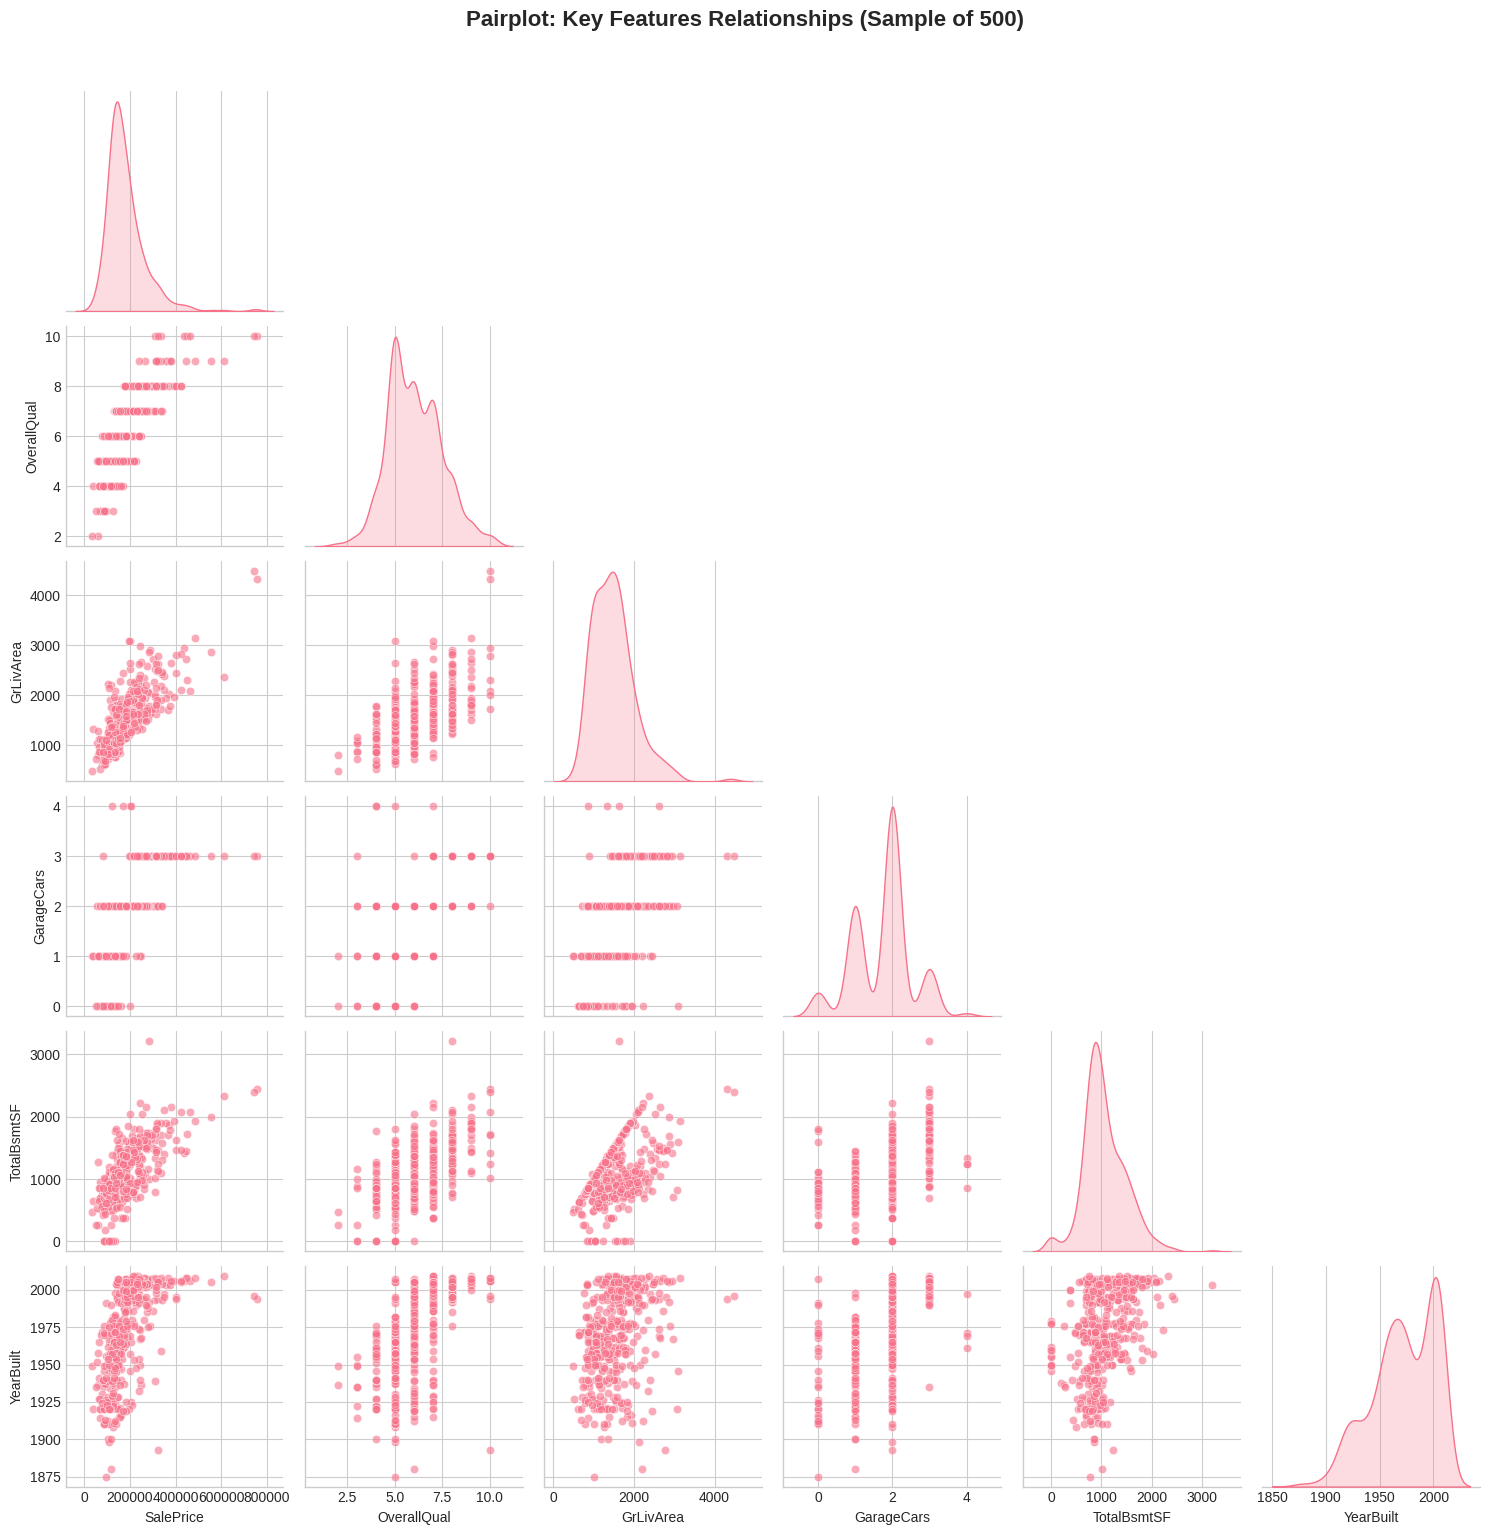

In [ ]:
# Pairplot for top features (sample for performance)
pair_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
pair_df = df[pair_features].sample(n=min(500, len(df)), random_state=42)  # Sample for performance

g = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.6}, corner=True,
                 diag_kws={'fill': True})
g.fig.suptitle('Pairplot: Key Features Relationships (Sample of 500)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

El pairplot muestra que el precio de venta de las viviendas está relacionado principalmente con la calidad general, el tamaño habitable, el área del sótano, la capacidad del garaje y el año de construcción. Se observa que las casas con mejor calidad, mayor espacio y más nuevas tienden a venderse a precios más altos.

Las relaciones más fuertes parecen darse entre SalePrice y OverallQual, y entre SalePrice y GrLivArea, lo que indica que la calidad y el tamaño son factores clave en el valor de una vivienda. También se aprecia que casas grandes suelen tener sótanos más amplios y garajes con mayor capacidad.

In [ ]:
# ============================================
# REVISAR VALORES NULOS
# ============================================

print("Valores nulos por variable:\n")

nulls = df.isnull().sum()

nulls_df = pd.DataFrame({
    "Variable": nulls.index,
    "Nulos": nulls.values,
    "Porcentaje (%)": (nulls.values / len(df)) * 100
})

# Mostrar solo variables con nulos
nulls_df = nulls_df[nulls_df["Nulos"] > 0].sort_values(
    by="Nulos",
    ascending=False
)

display(nulls_df)

print(f"Total de variables con valores nulos: {len(nulls_df)}")

Valores nulos por variable:



,Variable,Nulos,Porcentaje (%)
72,PoolQC,1453,99.520548
74,MiscFeature,1406,96.301370
6,Alley,1369,93.767123
73,Fence,1179,80.753425
25,MasVnrType,872,59.726027
57,FireplaceQu,690,47.260274
3,LotFrontage,259,17.739726
58,GarageType,81,5.547945
59,GarageYrBlt,81,5.547945
60,GarageFinish,81,5.547945


Total de variables con valores nulos: 19


In [ ]:
df = df.drop(columns=["PoolQC", "Alley", "Fence", "MiscFeature"])

In [ ]:
# ============================================
# VARIABLES
# ============================================
# Variable objetivo:
# SalePrice = precio de venta de la vivienda

X = df.drop(columns=["SalePrice", "Id"], errors="ignore")
y = df["SalePrice"]

In [ ]:
# ============================================
# VARIABLES NUMÉRICAS Y CATEGÓRICAS
# ============================================
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))

Variables numéricas: 36
Variables categóricas: 39


In [ ]:
# ============================================
# PREPROCESAMIENTO
# ============================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


In [ ]:
# ============================================
# MODELOS
# ============================================
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Bagging": BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=100,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "AdaBoost": AdaBoostRegressor(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective="reg:squarederror",
        random_state=42
    )
}

In [ ]:
# ============================================
# VALIDACIÓN CRUZADA - 10 FOLDS
# ============================================
cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

resultados = {}

for name, model in models.items():

    print(f"\n==============================")
    print(f"MODELO: {name}")
    print(f"==============================")

    pipe = Pipeline([
        ("preprocessor", preprocess),
        ("model", model)
    ])
    cv_results = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring="neg_mean_squared_error",
        return_train_score=False,
        n_jobs=-1
    )

    # Convertimos a ECM positivo
    mse_folds = -cv_results["test_score"]

    folds_df = pd.DataFrame({
        "ECM": mse_folds
    })

    folds_df.index = [f"Fold {i+1}" for i in range(10)]

    print("Resultados por fold:")
    display(folds_df.round(2))

    print("Resumen estadístico:")
    display(folds_df.describe().round(2))

    resultados[name] = mse_folds.mean()


MODELO: Decision Tree
Resultados por fold:


,ECM
Fold 1,1.264454e+09
Fold 2,1.754015e+09
Fold 3,1.238266e+09
Fold 4,2.646566e+09
Fold 5,1.568120e+09
Fold 6,1.523999e+09
Fold 7,1.770185e+09
Fold 8,1.909070e+09
Fold 9,1.510691e+09
Fold 10,1.299998e+09


Resumen estadístico:


,ECM
count,1.000000e+01
mean,1.648537e+09
std,4.174212e+08
min,1.238266e+09
25%,1.352671e+09
50%,1.546060e+09
75%,1.766143e+09
max,2.646566e+09



MODELO: Bagging
Resultados por fold:


...

,ECM
count,1.000000e+01
mean,1.304338e+09
std,3.709264e+08
min,7.306413e+08
25%,1.158241e+09
50%,1.305696e+09
75%,1.416061e+09
max,2.130010e+09



MODELO: XGBoost
Resultados por fold:


,ECM
Fold 1,6.811039e+08
Fold 2,7.551380e+08
Fold 3,3.923088e+08
Fold 4,1.163009e+09
Fold 5,2.013010e+09
Fold 6,7.295883e+08
Fold 7,9.978908e+08
Fold 8,7.128073e+08
Fold 9,4.811536e+08
Fold 10,5.190780e+08


Resumen estadístico:


,ECM
count,1.000000e+01
mean,8.445088e+08
std,4.711712e+08
min,3.923088e+08
25%,5.595845e+08
50%,7.211978e+08
75%,9.372026e+08
max,2.013010e+09


In [ ]:
# ============================================
# VALIDACIÓN CRUZADA (10 FOLDS) — ECM POSITIVO
# ============================================

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np

cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

resultados = {}

for name, model in models.items():

    print(f"\n==============================")
    print(f"MODELO: {name}")
    print(f"==============================")

    pipe = Pipeline([
        ("preprocessor", preprocess),
        ("model", model)
    ])

    mse_folds = []

    # Hacemos manualmente los 10 folds
    for train_idx, test_idx in cv.split(X):

        X_train_fold = X.iloc[train_idx]
        X_test_fold = X.iloc[test_idx]

        y_train_fold = y.iloc[train_idx]
        y_test_fold = y.iloc[test_idx]

        # Entrenar modelo
        pipe.fit(X_train_fold, y_train_fold)

        # Predecir
        y_pred_fold = pipe.predict(X_test_fold)

        # Calcular ECM directamente (positivo)
        mse = mean_squared_error(y_test_fold, y_pred_fold)

        mse_folds.append(mse)

    # Guardar resultados
    folds_df = pd.DataFrame({
        "ECM": mse_folds
    })

    folds_df.index = [f"Fold {i+1}" for i in range(10)]

    print("Resultados por fold:")
    display(folds_df.round(2))

    print("Resumen estadístico:")
    display(folds_df.describe().round(2))

    resultados[name] = np.mean(mse_folds)


MODELO: Decision Tree
Resultados por fold:


,ECM
Fold 1,1.264454e+09
Fold 2,1.754015e+09
Fold 3,1.238266e+09
Fold 4,2.646566e+09
Fold 5,1.568120e+09
Fold 6,1.523999e+09
Fold 7,1.770185e+09
Fold 8,1.909070e+09
Fold 9,1.510691e+09
Fold 10,1.299998e+09


Resumen estadístico:


,ECM
count,1.000000e+01
mean,1.648537e+09
std,4.174212e+08
min,1.238266e+09
25%,1.352671e+09
50%,1.546060e+09
75%,1.766143e+09
max,2.646566e+09



MODELO: Bagging
Resultados por fold:


...

,ECM
count,1.000000e+01
mean,1.304338e+09
std,3.709264e+08
min,7.306413e+08
25%,1.158241e+09
50%,1.305696e+09
75%,1.416061e+09
max,2.130010e+09



MODELO: XGBoost
Resultados por fold:


,ECM
Fold 1,6.811039e+08
Fold 2,7.551380e+08
Fold 3,3.923088e+08
Fold 4,1.163009e+09
Fold 5,2.013010e+09
Fold 6,7.295883e+08
Fold 7,9.978908e+08
Fold 8,7.128073e+08
Fold 9,4.811536e+08
Fold 10,5.190780e+08


Resumen estadístico:


,ECM
count,1.000000e+01
mean,8.445088e+08
std,4.711712e+08
min,3.923088e+08
25%,5.595845e+08
50%,7.211978e+08
75%,9.372026e+08
max,2.013010e+09


In [ ]:
# ============================================
# COMPARACIÓN FINAL
# ============================================
resultados_df = pd.DataFrame.from_dict(
    resultados,
    orient="index",
    columns=["ECM Promedio"]
).sort_values("ECM Promedio")

print("\n======================================")
print("COMPARACIÓN FINAL DE MODELOS")
print("======================================")

display(resultados_df.round(2))

print("\nMejor modelo:")
print(resultados_df.index[0])


COMPARACIÓN FINAL DE MODELOS


,ECM Promedio
XGBoost,8.445088e+08
Random Forest,8.577373e+08
Bagging,8.813755e+08
AdaBoost,1.304338e+09
Decision Tree,1.648537e+09



Mejor modelo:
XGBoost


La comparación final de modelos muestra que XGBoost fue el mejor algoritmo para predecir el precio de las viviendas, ya que obtuvo el menor ECM Promedio (Error Cuadrático Medio), lo que indica que sus predicciones presentan el menor error promedio frente a los valores reales. Esto significa que fue el modelo con mayor capacidad para capturar la relación entre las variables del dataset y el precio de venta (SalePrice).

En segundo lugar se ubicó Random Forest, seguido por Bagging, mostrando también un buen desempeño, aunque ligeramente inferior al de XGBoost. Por otro lado, AdaBoost y especialmente Decision Tree presentaron errores considerablemente más altos, lo que indica una menor precisión predictiva. Esto sugiere que los modelos de ensamble superan claramente al árbol de decisión individual, ya que combinan múltiples árboles y logran reducir mejor el error y el sobreajuste.

XGBoost fue seleccionado como el mejor modelo del proyecto debido a su mayor capacidad predictiva, mejor generalización y menor error, convirtiéndose en la mejor alternativa para estimar el precio de las viviendas dentro de este problema de regresión.

In [ ]:
   # ============================================
# PUNTO 6
# GRID SEARCH — HIPERPARÁMETROS
# HOUSE PRICES
# ============================================

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# ============================================
# TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ============================================
# 1. DECISION TREE
# ============================================

dt_pipe = Pipeline([
    ("preprocessor", preprocess),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_params = {
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    dt_pipe,
    dt_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("===== DECISION TREE =====")
print("Mejores parámetros:")
print(dt_grid.best_params_)
print("Mejor ECM CV:")
print(-dt_grid.best_score_)


# ============================================
# 2. RANDOM FOREST
# ============================================

rf_pipe = Pipeline([
    ("preprocessor", preprocess),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("\n===== RANDOM FOREST =====")
print("Mejores parámetros:")
print(rf_grid.best_params_)
print("Mejor ECM CV:")
print(-rf_grid.best_score_)


# ============================================
# 3. ADABOOST
# ============================================

ada_pipe = Pipeline([
    ("preprocessor", preprocess),
    ("model", AdaBoostRegressor(random_state=42))
])

ada_params = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.1, 1]
}

ada_grid = GridSearchCV(
    ada_pipe,
    ada_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

ada_grid.fit(X_train, y_train)

print("\n===== ADABOOST =====")
print("Mejores parámetros:")
print(ada_grid.best_params_)
print("Mejor ECM CV:")
print(-ada_grid.best_score_)


# ============================================
# 4. XGBOOST
# ============================================

xgb_pipe = Pipeline([
    ("preprocessor", preprocess),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 6, 10],
    "model__learning_rate": [0.01, 0.1, 0.3]
}

xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("\n===== XGBOOST =====")
print("Mejores parámetros:")
print(xgb_grid.best_params_)
print("Mejor ECM CV:")
print(-xgb_grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
===== DECISION TREE =====
Mejores parámetros:
{'model__max_depth': 20, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
Mejor ECM CV:
1691459548.6810405
Fitting 5 folds for each of 12 candidates, totalling 60 fits

===== RANDOM FOREST =====
Mejores parámetros:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Mejor ECM CV:
945505282.8593414
Fitting 5 folds for each of 9 candidates, totalling 45 fits

===== ADABOOST =====
Mejores parámetros:
{'model__learning_rate': 0.1, 'model__n_estimators': 200}
Mejor ECM CV:
1308886931.3765101
Fitting 5 folds for each of 18 candidates, totalling 90 fits

===== XGBOOST =====
Mejores parámetros:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Mejor ECM CV:
814205139.2


Los resultados de la optimización de hiperparámetros mediante GridSearchCV muestran que el modelo con mejor desempeño fue nuevamente XGBoost, obteniendo el menor ECM en validación cruzada con un valor de 814.205.139, lo que confirma que es el modelo más preciso para predecir el precio de las viviendas. La mejor configuración encontrada fue 200 árboles (n_estimators = 200), una profundidad máxima de 3 (max_depth = 3) y una tasa de aprendizaje de 0.1 (learning_rate = 0.1), lo que indica que un modelo más controlado y menos profundo logra generalizar mejor sin sobreajustarse.

En segundo lugar se ubicó Random Forest, con un ECM de 945.505.282, utilizando 200 árboles, profundidad ilimitada (max_depth = None) y división mínima de 2 muestras. Esto demuestra que también es un modelo muy sólido, aunque ligeramente inferior a XGBoost. Por su parte, AdaBoost presentó un ECM de 1.308.886.931, con mejor rendimiento usando 200 estimadores y learning rate de 0.1, mientras que Decision Tree fue el modelo con peor desempeño, con un ECM de 1.691.459.548, incluso después de optimizar su profundidad y tamaño mínimo de hojas.

Estos resultados refuerzan que los modelos de ensamble, especialmente XGBoost y Random Forest, superan ampliamente al árbol de decisión individual, ya que logran reducir el error de predicción y mejorar la capacidad de generalización del modelo. Por esta razón, XGBoost fue seleccionado como el mejor modelo final del proyecto.

In [ ]:
# ============================================
# PUNTO 7
# COMPARACIÓN DE MODELOS Y MEJOR MODELO
# ============================================

from sklearn.metrics import mean_squared_error, r2_score

# ============================================
# GUARDAR LOS MEJORES MODELOS
# ============================================

best_models = {
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "AdaBoost": ada_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

resultados_finales = {}

# ============================================
# EVALUACIÓN EN TEST
# ============================================

for name, model in best_models.items():

    # Predicción
    y_pred = model.predict(X_test)

    # Métricas
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    resultados_finales[name] = {
        "ECM": mse,
        "R2": r2
    }

    print(f"\n==============================")
    print(f"MODELO: {name}")
    print(f"==============================")
    print(f"ECM: {mse:.2f}")
    print(f"R2: {r2:.4f}")

# ============================================
# TABLA COMPARATIVA FINAL
# ============================================

resultados_df = pd.DataFrame(resultados_finales).T

# Ordenar por menor ECM
resultados_df = resultados_df.sort_values("ECM")

print("\n======================================")
print("COMPARACIÓN FINAL DE MODELOS")
print("======================================")

display(resultados_df.round(2))

# ============================================
# MEJOR MODELO
# ============================================

mejor_modelo_nombre = resultados_df.index[0]
mejor_modelo = best_models[mejor_modelo_nombre]

print("\n======================================")
print("MEJOR MODELO")
print("======================================")
print("El mejor modelo fue:", mejor_modelo_nombre)
print("\nPorque presentó el menor ECM y el mejor ajuste en la predicción del precio de las viviendas.")


MODELO: Decision Tree
ECM: 1695021940.88
R2: 0.7790

MODELO: Random Forest
ECM: 823180040.21
R2: 0.8927

MODELO: AdaBoost
ECM: 1156875500.54
R2: 0.8492

MODELO: XGBoost
ECM: 655136704.00
R2: 0.9146

COMPARACIÓN FINAL DE MODELOS


,ECM,R2
XGBoost,6.551367e+08,0.91
Random Forest,8.231800e+08,0.89
AdaBoost,1.156876e+09,0.85
Decision Tree,1.695022e+09,0.78



MEJOR MODELO
El mejor modelo fue: XGBoost

Porque presentó el menor ECM y el mejor ajuste en la predicción del precio de las viviendas.


La evaluación final de los modelos en el conjunto de prueba confirma que XGBoost fue el mejor modelo para predecir el precio de las viviendas, ya que obtuvo el menor ECM (655.136.704) y el mayor R² (0.9146). Esto significa que sus predicciones fueron las más precisas y que logró explicar aproximadamente el 91% de la variabilidad del precio de venta (SalePrice), mostrando una excelente capacidad de ajuste y generalización.

En segundo lugar se ubicó Random Forest, con un ECM de 823.180.040 y un R² de 0.8927, lo que también representa un desempeño muy sólido, aunque ligeramente inferior al de XGBoost. Esto indica que ambos modelos de ensamble fueron altamente efectivos para capturar la relación entre las variables del dataset y el precio de las viviendas. Por su parte, AdaBoost presentó un rendimiento intermedio, con un ECM de 1.156.875.500 y un R² de 0.8492, mientras que Decision Tree fue el modelo con peor desempeño, obteniendo el mayor error (1.695.021.940) y el menor R² (0.7790), lo que evidencia una menor capacidad predictiva.

In [ ]:
# ============================================
# PUNTO 8
# GUARDAR EL MEJOR MODELO CON JOBLIB
# ============================================

import joblib

# ============================================
# GUARDAR EL MEJOR MODELO
# ============================================

# mejor_modelo ya viene del punto 7
# (el modelo con menor ECM)

joblib.dump(
    mejor_modelo,
    "mejor_modelo_house_prices.pkl"
)

print("Modelo guardado correctamente")

print("\nNombre del archivo:")
print("mejor_modelo_house_prices.pkl")

Modelo guardado correctamente

Nombre del archivo:
mejor_modelo_house_prices.pkl
